In [1]:
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v2 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
folder = 'out/z_scored/dmfc_rsg/00003-dmfc_rsg-prr-uncond-regularFM-gpus1-batch256-fp32'
pkl_path = folder + '/network-snapshot-500000.pkl'

# function

In [3]:
def plotTraj(data, data_sim = None, title = None):
    data_min = np.min(data)
    data_max = np.max(data)
    data_range = data_max - data_min
    offset = data_range * 1.1

    time = np.arange(data.shape[0])
    if data_sim is not None:
        time_sim = np.arange(data_sim.shape[0])
    
    # Plot the trajectories
    plt.figure(figsize=(6, 4))  # Adjust figure size as needed
    for i in range(data.shape[1]):
        adjusted_y = data[:, i] + i * offset
        plt.plot(time, adjusted_y, label=f'Trajectory {i+1}', linewidth=0.5, c='red') 
        if data_sim is not None:
            adjusted_y_sim = data_sim[:, i] + i * offset
            plt.plot(time_sim, adjusted_y_sim, label=f'Trajectory {i+1}', linewidth=0.5, c='black')
        
    # Customize the plot
    plt.xlabel('Time')
    plt.tight_layout()
    if title is not None:
        plt.title(title)
    plt.show()

# 1. Load Data

In [4]:
dataset_samples = np.load(folder + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']

In [5]:
len(data_raw)

748

In [6]:
T_max = 0
T_min = 1000000
for ii in range(len(data_raw)):
    T_max = max(data_raw[ii].shape[0], T_max)
    T_min = min(data_raw[ii].shape[0], T_min)

In [7]:
[T_min, T_max]

[1866, 5616]

In [8]:
data_raw[0].shape

(2967, 40)

In [9]:
dataFolder = 'data/dmfc_rsg'

In [10]:
mean_std = np.load(dataFolder + "/mean_std.npy")

In [11]:
# mean_std

# 2. Load Model

In [12]:
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)


In [13]:
if 'ema' in model_all:
    net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else:
    net = model_all['net']  # Raw trained model

In [14]:
net = net.to(device).eval()

In [15]:
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

# 3. Generate path

In [16]:
starting_pts = np.zeros((len(data_raw), data_raw[0].shape[1]))
for ii in range(len(data_raw)):
    starting_pts[ii,:] = data_raw[ii][0,:]
starting_pts = torch.from_numpy(starting_pts).unsqueeze(1).type(torch.float32).to(device) #ntrajs,1,dim

## 3.1 dynamics in ambience space

In [17]:
curr_tau_pts = starting_pts
n_step = T_min
tau = 1.0
curr_tau_trajs = []
curr_tau_trajs.append(curr_tau_pts.cpu().numpy())

for ii in tqdm(range(n_step-1)):
    x0_tau = curr_tau_pts.squeeze(1)  # Current points become the starting points for this dynamics step
    curr_tau_pts = util.calc_dyn_trajectories(dyn_net, curr_tau_pts.squeeze(1), tau, x0_tau=x0_tau, nt=2)
    curr_tau_pts = curr_tau_pts[-1].unsqueeze(1)
    curr_tau_trajs.append(curr_tau_pts.cpu().numpy())

100%|██████████████████████████████████████| 1865/1865 [00:11<00:00, 156.15it/s]


In [18]:
curr_tau_trajs = np.concatenate(curr_tau_trajs, axis=1) #n_trajs, traj_len+1, dim
curr_tau_trajs.shape

(748, 1866, 40)

In [19]:
data_raw_back = data_raw.copy()
curr_tau_trajs_back = curr_tau_trajs.copy()
for ii in range(len(data_raw)):
    data_raw_back[ii] = data_raw[ii] * mean_std[1] + mean_std[0]
    curr_tau_trajs_back[ii] = curr_tau_trajs[ii] * mean_std[1] + mean_std[0]
    curr_tau_trajs_back[ii][curr_tau_trajs_back[ii] < 0.] = 0.

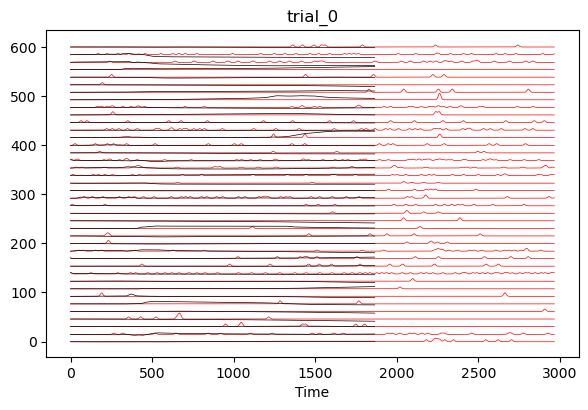

In [20]:
trial_plot = 0
# plotTraj(data_raw_back[trial_plot], data_sim = curr_tau_trajs_back[trial_plot,:,:], title = 'trial_' + str(trial_plot))
plotTraj(data_raw[trial_plot], data_sim = curr_tau_trajs[trial_plot,:,:], title = 'trial_' + str(trial_plot))

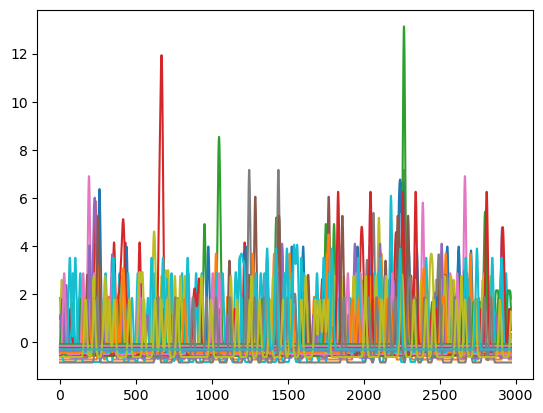

In [21]:
# data
# plt.plot(data_raw_back[trial_plot]);
plt.plot(data_raw[trial_plot]);
# plt.ylim([-12, 15]);

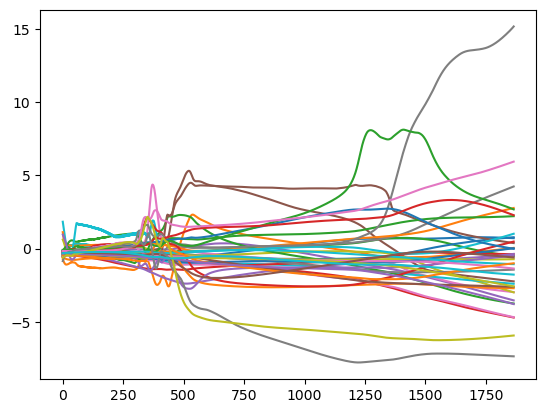

In [22]:
# simulated: didn't catch the dynamics...
# plt.plot(curr_tau_trajs_back[trial_plot,:,:]);
plt.plot(curr_tau_trajs[trial_plot,:,:]);
# plt.ylim([-12, 15]);

## 3.2 dynamics in latent space

In [ ]:
tau = 0.
start_tau = 1.
curr_tau_starting_pts = util.calc_flow_trajectories(flow_net, starting_pts.squeeze(1), start_tau, tau, nt=2)

In [ ]:
curr_tau_starting_pts.shape

In [ ]:
curr_tau_pts_latent = curr_tau_starting_pts[-1].unsqueeze(1) 

In [ ]:
curr_tau_trajs_latent = []
curr_tau_trajs_latent.append(curr_tau_pts_latent.cpu().numpy())

In [ ]:
for ii in tqdm(range(n_step-1)):
    x0_tau_latent = curr_tau_pts_latent.squeeze(1)
    curr_tau_pts_latent = util.calc_dyn_trajectories(dyn_net, curr_tau_pts_latent.squeeze(1), tau, x0_tau=x0_tau_latent, nt=2)
    curr_tau_pts_latent = curr_tau_pts_latent[-1].unsqueeze(1)
    curr_tau_trajs_latent.append(curr_tau_pts_latent.cpu().numpy())
curr_tau_trajs_latent = np.concatenate(curr_tau_trajs_latent, axis=1) #n_trajs, traj_len+1, dim

In [ ]:
curr_tau_trajs_latent.shape

TODO:

1. how to get D matrix at each time, so I can plot the low-D trajectories... 